# Notebook 03: LLM Benchmark (Main Evaluation)

Main evaluation of OpenAI's GPT-5.5 as a topic classifier for ERP/SaaS
contract sections, using the prompt formulation selected in Notebook 02.
Produces metrics directly comparable to Notebook 01 (encoder benchmark),
under the same statistical machinery and on the same 64 labelled sections.

## Methodology

**Task.** Same as Notebooks 01 and 02: predict one of 76 catalogue
topics for each contract section, compare against the manually assigned
`catalog_id`.

**System under evaluation.** OpenAI's `gpt-5.5-2026-04-23` accessed
through the Chat Completions API with structured outputs.

**Prompt formulation.** Determined empirically in Notebook 02. Set the
`SELECTED_VARIANT` constant below to the value chosen there.

**Force-choice formulation.** A JSON Schema constrains the model's
output to one integer in {1, ..., 76}, plus a brief textual reasoning.

**Reasoning capture.** The model is asked for a brief explanation of
its choice for the transparency analysis in Chapter 7.

**Statistical inference.** Bootstrap CIs (B=1000) on the 64-section set,
identical to Notebook 01.

**Stability protocol.** N=5 runs with identical configuration.
Stability score is the fraction of sections for which all five runs
return the same catalog_id.

## Setup

In [ ]:
import json
import sys
import time
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

sys.path.insert(0, str(PROJECT_ROOT))
from src import metrics as M

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "llm"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# === Configuration ===
LLM_MODEL = "gpt-5.5-2026-04-23"
SEED = 42
N_STABILITY_RUNS = 5
N_BOOTSTRAP_RESAMPLES = 1000
DELAY_BETWEEN_CALLS = 1.0


# SELECTED_VARIANT must match the highest-F1 variant from Notebook 02.
# Run Notebook 02 first, then set this constant to the printed selection.
SELECTED_VARIANT = "B_paragraph_section"      # <-- update after Notebook 02

client = OpenAI()
print(f"Model: {LLM_MODEL}")
print(f"Selected prompt variant: {SELECTED_VARIANT}")

Model: gpt-5.5-2026-04-23
Selected prompt variant: B_paragraph_section


In [19]:
# Suppress harmless sklearn warnings about high class count relative to sample size
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Step 1: Load data

In [2]:
sections = pd.read_excel(DATA_DIR / "sections_labeled_manually.xlsx")
sections = sections.drop(columns=["Unnamed: 0"], errors="ignore")

catalogue_raw = pd.read_excel(DATA_DIR / "catalogue_clean_with_aspects.xlsx")
catalogue = catalogue_raw[["paragraph_topic", "section_topic", "example"]].copy()
catalogue["catalog_id"] = catalogue.index + 1

gold_ids = set(sections["catalog_id"])
catalogue_ids = set(catalogue["catalog_id"])
assert gold_ids.issubset(catalogue_ids)
print(f"Sections: {len(sections)}, Catalogue: {len(catalogue)}")

Sections: 64, Catalogue: 76


## Step 2: Prompt construction

The renderer functions are the same five from Notebook 02. The
`SELECTED_VARIANT` constant at the top of the notebook controls which
one is used.

In [3]:
def render_A_section_only(row: pd.Series) -> str:
    return f"[ID {row['catalog_id']}] {row['section_topic']}"


def render_B_paragraph_section(row: pd.Series) -> str:
    return (
        f"[ID {row['catalog_id']}] {row['paragraph_topic']}\n"
        f"        {row['section_topic']}"
    )


def render_C_example_only(row: pd.Series) -> str:
    return f"[ID {row['catalog_id']}] {row['example']}"


def render_D_section_example(row: pd.Series) -> str:
    return (
        f"[ID {row['catalog_id']}] {row['section_topic']}\n"
        f"        Example: {row['example']}"
    )


def render_E_all(row: pd.Series) -> str:
    return (
        f"[ID {row['catalog_id']}] {row['paragraph_topic']}\n"
        f"        {row['section_topic']}\n"
        f"        Example: {row['example']}"
    )


VARIANT_RENDERERS = {
    "A_section_only":      render_A_section_only,
    "B_paragraph_section": render_B_paragraph_section,
    "C_example_only":      render_C_example_only,
    "D_section_example":   render_D_section_example,
    "E_all_fields":        render_E_all,
}

assert SELECTED_VARIANT in VARIANT_RENDERERS, (
    f"SELECTED_VARIANT '{SELECTED_VARIANT}' not in VARIANT_RENDERERS. "
    f"Run Notebook 02 and set this constant."
)

active_renderer = VARIANT_RENDERERS[SELECTED_VARIANT]
catalogue_text = "\n\n".join(active_renderer(row) for _, row in catalogue.iterrows())

SYSTEM_PROMPT = f"""You are an expert in ERP and SaaS contract analysis. Your task is to classify a given contract section into one of 76 predefined catalogue topics.

Each catalogue entry is identified by an integer ID (1 to 76). You must select the single ID that best matches what the contract section addresses semantically.

Contract sections are written in German.

Catalogue:

{catalogue_text}

Output exactly one ID between 1 and 76, plus a brief explanation (max 30 words) of why this ID matches."""

USER_PROMPT_TEMPLATE = """Contract section to classify:

{section_text}

Which catalogue ID best matches this section?"""

print(f"System prompt length: {len(SYSTEM_PROMPT):,} characters")
print(f"Variant active: {SELECTED_VARIANT}")
print(f"\nFirst 500 characters of system prompt:\n")
print(SYSTEM_PROMPT[:500])
print("\n...")

System prompt length: 13,567 characters
Variant active: B_paragraph_section

First 500 characters of system prompt:

You are an expert in ERP and SaaS contract analysis. Your task is to classify a given contract section into one of 76 predefined catalogue topics.

Each catalogue entry is identified by an integer ID (1 to 76). You must select the single ID that best matches what the contract section addresses semantically.

Contract sections are written in German.

Catalogue:

[ID 1] Projektkosten_und_Zahlungsmodalitäten
        Sind sämtliche Kostenarten und -bestandteile (einmalig und laufend) im Vertrag tran

...


## Step 3: Structured output schema

Pydantic model constraining `catalog_id` to integers 1 to 76 plus a
reasoning field. The schema is enforced by OpenAI's Structured Outputs
API.

In [4]:
class ClassificationResult(BaseModel):
    catalog_id: int = Field(
        description="The catalog_id of the best matching catalogue entry, between 1 and 76",
        ge=1,
        le=76,
    )
    reasoning: str = Field(
        description="Brief explanation of why this ID matches, maximum 30 words.",
    )

## Step 4: Classification function

In [5]:
def classify_section_with_llm(
    section_text: str,
    model: str = LLM_MODEL,
    seed: Optional[int] = SEED,
) -> dict:
    """Single LLM call to classify one contract section."""
    completion = client.chat.completions.parse(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_PROMPT_TEMPLATE.format(section_text=section_text)},
        ],
        response_format=ClassificationResult,
        seed=seed,
    )

    result = completion.choices[0].message.parsed
    usage = completion.usage

    return {
        "catalog_id": result.catalog_id,
        "reasoning": result.reasoning,
        "input_tokens": usage.prompt_tokens,
        "output_tokens": usage.completion_tokens,
        "cached_tokens": getattr(usage.prompt_tokens_details, "cached_tokens", 0)
                         if hasattr(usage, "prompt_tokens_details") else 0,
        "system_fingerprint": completion.system_fingerprint,
    }

## Step 5: Smoke test

In [6]:
test_section = sections.iloc[0]
test_text = test_section["section_content"]
test_gold = test_section["catalog_id"]

print(f"Section: {test_text[:200]}...")
print(f"Gold: {test_gold}\n")
print("Calling LLM ...")

test_result = classify_section_with_llm(test_text)
print(f"\nPredicted catalog_id: {test_result['catalog_id']}")
print(f"Reasoning: {test_result['reasoning']}")
print(f"Tokens: input={test_result['input_tokens']}, output={test_result['output_tokens']}, cached={test_result['cached_tokens']}")
print(f"Correct: {test_result['catalog_id'] == test_gold}")

Section: (1) Zahlungszeitraum und Höhe der  richten sich ebenso wie die Zahlungsweise nach dem jeweils gültigen Preisverzeichnis....
Gold: 1

Calling LLM ...

Predicted catalog_id: 6
Reasoning: Die Vergütungshöhe richtet sich nach dem jeweils gültigen Preisverzeichnis, was auf variable bzw. änderbare Preise während der Vertragslaufzeit verweist.
Tokens: input=3438, output=569, cached=0
Correct: False


## Step 6: Primary classification pass

Run over all 64 sections once.

In [7]:
def classify_all_sections(section_texts: list, label: str = "primary", delay: float = DELAY_BETWEEN_CALLS) -> pd.DataFrame:
    rows = []
    for i, text in enumerate(section_texts):
        result = classify_section_with_llm(text)
        rows.append(result)
        if (i + 1) % 10 == 0 or (i + 1) == len(section_texts):
            print(f"  [{label}] {i + 1} / {len(section_texts)} done")
        if i < len(section_texts) - 1:
            time.sleep(delay)
    return pd.DataFrame(rows)


section_texts = sections["section_content"].tolist()
print(f"Starting primary pass over {len(section_texts)} sections ...\n")
start = time.time()
primary_results = classify_all_sections(section_texts, label="primary run")
elapsed = time.time() - start
print(f"\nElapsed: {elapsed:.1f} seconds")

total_input = primary_results["input_tokens"].sum()
total_output = primary_results["output_tokens"].sum()
total_cached = primary_results["cached_tokens"].sum()
primary_cost = (
    (total_input - total_cached) * 5.0 / 1_000_000
    + total_cached * 2.5 / 1_000_000
    + total_output * 30.0 / 1_000_000
)
print(f"Tokens: input={total_input:,} ({total_cached:,} cached), output={total_output:,}")
print(f"Primary run cost: ${primary_cost:.4f}")

Starting primary pass over 64 sections ...

  [primary run] 10 / 64 done
  [primary run] 20 / 64 done
  [primary run] 30 / 64 done
  [primary run] 40 / 64 done
  [primary run] 50 / 64 done
  [primary run] 60 / 64 done
  [primary run] 64 / 64 done

Elapsed: 317.2 seconds
Tokens: input=226,416 (174,592 cached), output=7,804
Primary run cost: $0.9297


In [8]:
predictions_df = pd.DataFrame({
    "contract": sections["contract"].values,
    "paragraph": sections["paragraph"].values,
    "section": sections["section"].values,
    "section_content": sections["section_content"].values,
    "gold_catalog_id": sections["catalog_id"].values,
    "predicted_catalog_id": primary_results["catalog_id"].values,
    "reasoning": primary_results["reasoning"].values,
    "input_tokens": primary_results["input_tokens"].values,
    "output_tokens": primary_results["output_tokens"].values,
    "cached_tokens": primary_results["cached_tokens"].values,
    "system_fingerprint": primary_results["system_fingerprint"].values,
})
predictions_df["correct"] = predictions_df["gold_catalog_id"] == predictions_df["predicted_catalog_id"]

print(f"Primary pass complete: {predictions_df['correct'].sum()} / {len(predictions_df)} correct")
print(f"Accuracy: {predictions_df['correct'].mean():.4f}")
predictions_df[["paragraph", "section", "gold_catalog_id", "predicted_catalog_id", "correct", "reasoning"]].head(10)

Primary pass complete: 47 / 64 correct
Accuracy: 0.7344


,paragraph,section,gold_catalog_id,predicted_catalog_id,correct,reasoning
0,§ 7,(1),1,4,False,"Die Klausel verweist für Zahlungszeitraum, Höh..."
1,§ 12,(2),69,69,True,Regelt außerordentliche Kündigung aus wichtige...
2,3.,3.2,31,31,True,Regelt Folgen bei SLA-Verfehlung: Service Leve...
3,5.,5.2,8,8,True,"Regelt Verzugszinsen und das Recht von SAP, be..."
4,6.,6.3,70,70,True,Regelt die anteilige Rückerstattung vorausbeza...
5,12.,12.4,71,71,True,Die Klausel regelt Abtretung bzw. Übertragung ...
6,12.,12.5,72,72,True,Die Klausel legt ausdrücklich deutsches Recht ...
7,2.,2.4,16,32,False,"Der Abschnitt beschreibt Supportkanäle, Verfüg..."
8,2.,2.1,3,4,False,"Regelt Zahlungsfrist ab Rechnung, Steuerpflich..."
9,3.,3.1,39,47,False,Regelt Eigentums- bzw. Schutzrechte an im Rahm...


## Step 7: Point metrics and bootstrap CIs

Identical evaluation machinery as Notebook 01.

In [20]:
y_true = predictions_df["gold_catalog_id"].values
y_pred = predictions_df["predicted_catalog_id"].values

point_metrics = M.compute_point_metrics(y_true, y_pred)
print("Point metrics:")
for name, value in point_metrics.items():
    print(f"  {name:25s} {value:.4f}")

Point metrics:
  accuracy                  0.7344
  precision_macro           0.6263
  precision_weighted        0.6380
  recall_macro              0.7258
  recall_weighted           0.7344
  f1_macro                  0.6559
  f1_weighted               0.6667


In [21]:
print(f"Computing bootstrap CIs with B = {N_BOOTSTRAP_RESAMPLES} resamples ...")
ci_results = M.bootstrap_confidence_intervals(
    y_true, y_pred,
    n_resamples=N_BOOTSTRAP_RESAMPLES,
    confidence=0.95,
    random_state=SEED,
)

ci_table = pd.DataFrame([
    {"metric": name, "point": v["point"], "ci_low": v["ci_low"], "ci_high": v["ci_high"], "ci_width": v["ci_high"] - v["ci_low"]}
    for name, v in ci_results.items()
])
ci_table

Computing bootstrap CIs with B = 1000 resamples ...


,metric,point,ci_low,ci_high,ci_width
0,accuracy,0.734375,0.625000,0.843750,0.218750
1,precision_macro,0.626344,0.507315,0.726195,0.218880
2,precision_weighted,0.638021,0.548952,0.795605,0.246654
3,recall_macro,0.725806,0.571429,0.783832,0.212403
4,recall_weighted,0.734375,0.625000,0.843750,0.218750
5,f1_macro,0.655914,0.528236,0.741285,0.213049
6,f1_weighted,0.666667,0.572891,0.810421,0.237531


## Step 8: Stability run (4 additional passes)

The primary run from Step 6 is the first of N=5 runs. Four additional
passes follow here. The OpenAI API is best-effort deterministic, so
expect Stability < 1.0.

In [11]:
all_results_per_run = [primary_results]
all_predictions_per_run = [primary_results["catalog_id"].values]
total_stability_cost = primary_cost

for run_idx in range(1, N_STABILITY_RUNS):
    print(f"\n--- Stability run {run_idx + 1} of {N_STABILITY_RUNS} ---")
    start = time.time()
    result_df = classify_all_sections(section_texts, label=f"stability run {run_idx + 1}")
    elapsed = time.time() - start

    run_input = result_df["input_tokens"].sum()
    run_output = result_df["output_tokens"].sum()
    run_cached = result_df["cached_tokens"].sum()
    run_cost = (
        (run_input - run_cached) * 5.0 / 1_000_000
        + run_cached * 2.5 / 1_000_000
        + run_output * 30.0 / 1_000_000
    )
    total_stability_cost += run_cost
    print(f"Elapsed: {elapsed:.1f}s, accuracy this run: {(result_df['catalog_id'].values == y_true).mean():.4f}, cost: ${run_cost:.4f}")

    all_results_per_run.append(result_df)
    all_predictions_per_run.append(result_df["catalog_id"].values)

print(f"\nTotal cost over {N_STABILITY_RUNS} runs: ${total_stability_cost:.4f}")


--- Stability run 2 of 5 ---
  [stability run 2] 10 / 64 done
  [stability run 2] 20 / 64 done
  [stability run 2] 30 / 64 done
  [stability run 2] 40 / 64 done
  [stability run 2] 50 / 64 done
  [stability run 2] 60 / 64 done
  [stability run 2] 64 / 64 done
Elapsed: 293.6s, accuracy this run: 0.7188, cost: $0.8936

--- Stability run 3 of 5 ---
  [stability run 3] 10 / 64 done
  [stability run 3] 20 / 64 done
  [stability run 3] 30 / 64 done
  [stability run 3] 40 / 64 done
  [stability run 3] 50 / 64 done
  [stability run 3] 60 / 64 done
  [stability run 3] 64 / 64 done
Elapsed: 309.0s, accuracy this run: 0.7344, cost: $0.9240

--- Stability run 4 of 5 ---
  [stability run 4] 10 / 64 done
  [stability run 4] 20 / 64 done
  [stability run 4] 30 / 64 done
  [stability run 4] 40 / 64 done
  [stability run 4] 50 / 64 done
  [stability run 4] 60 / 64 done
  [stability run 4] 64 / 64 done
Elapsed: 297.6s, accuracy this run: 0.7188, cost: $0.9037

--- Stability run 5 of 5 ---
  [stability 

In [22]:
stability, is_stable = M.stability_score(all_predictions_per_run)
print(f"Stability score: {stability:.4f}")
print(f"Sections with identical predictions across all {N_STABILITY_RUNS} runs: {is_stable.sum()} / {len(is_stable)}")
print(f"Sections with at least one disagreement: {(~is_stable).sum()}")

Stability score: 0.9219
Sections with identical predictions across all 5 runs: 59 / 64
Sections with at least one disagreement: 5


In [23]:
all_metrics_per_run = [M.compute_point_metrics(y_true, pred) for pred in all_predictions_per_run]
run_summary = M.summarise_metric_across_runs(all_metrics_per_run)
print(f"Metric variability across N={N_STABILITY_RUNS} runs:")
run_summary.round(4)

Metric variability across N=5 runs:


,mean,std,min,max
metric,,,,
accuracy,0.7250,0.0086,0.7188,0.7344
precision_macro,0.6113,0.0148,0.5968,0.6263
precision_weighted,0.6224,0.0157,0.6042,0.6380
recall_macro,0.7161,0.0088,0.7097,0.7258
recall_weighted,0.7250,0.0086,0.7188,0.7344
f1_macro,0.6429,0.0124,0.6312,0.6559
f1_weighted,0.6534,0.0128,0.6396,0.6667


## Step 8b: Pricing correction

The cost calculations in Step 6 (primary run) and Step 8 (stability runs)
used an incorrect cached-input discount of 50% ($2.50 per million tokens).
OpenAI's official pricing for GPT-5.5 applies a 90% discount, i.e. $0.50
per million cached input tokens. This cell recomputes `primary_cost`,
`total_stability_cost`, and provides a per-run cost breakdown using the
corrected formula. The corrected values feed directly into Step 11 (save
outputs), where they are persisted to metrics.json.

In [14]:
# === Pricing correction ===
INPUT_PRICE_PER_M = 5.00
OUTPUT_PRICE_PER_M = 30.00
CACHED_PRICE_PER_M = 0.50         # was 2.50 in original calculation


def compute_cost(input_tok, output_tok, cached_tok):
    return (
        (input_tok - cached_tok) * INPUT_PRICE_PER_M / 1_000_000
        + cached_tok * CACHED_PRICE_PER_M / 1_000_000
        + output_tok * OUTPUT_PRICE_PER_M / 1_000_000
    )


# Preserve original values for transparency
total_stability_cost_uncorrected = total_stability_cost
primary_cost_uncorrected = primary_cost

# Recompute primary run cost
primary_cost = compute_cost(
    primary_results["input_tokens"].sum(),
    primary_results["output_tokens"].sum(),
    primary_results["cached_tokens"].sum(),
)

# Recompute total across all stability runs and build a per-run breakdown
run_cost_breakdown = []
total_stability_cost = 0.0
for i, df in enumerate(all_results_per_run):
    cost = compute_cost(
        df["input_tokens"].sum(),
        df["output_tokens"].sum(),
        df["cached_tokens"].sum(),
    )
    total_stability_cost += cost
    run_cost_breakdown.append({
        "run": i + 1,
        "input_tokens": int(df["input_tokens"].sum()),
        "output_tokens": int(df["output_tokens"].sum()),
        "cached_tokens": int(df["cached_tokens"].sum()),
        "cost_usd": cost,
    })

run_cost_df = pd.DataFrame(run_cost_breakdown)
print("Per-run cost breakdown (corrected):\n")
print(run_cost_df.to_string(index=False))
print(f"\nPrimary run cost:                  ${primary_cost:.4f}  (uncorrected: ${primary_cost_uncorrected:.4f})")
print(f"Total cost over {N_STABILITY_RUNS} stability runs: ${total_stability_cost:.4f}  (uncorrected: ${total_stability_cost_uncorrected:.4f})")

Per-run cost breakdown (corrected):

 run  input_tokens  output_tokens  cached_tokens  cost_usd
   1        226416           7804         174592  0.580536
   2        226416           7069         180224  0.533142
   3        226416           8084         180224  0.563592
   4        226416           7406         180224  0.543252
   5        226416           8454         180224  0.574692

Primary run cost:                  $0.5805  (uncorrected: $0.9297)
Total cost over 5 stability runs: $2.7952  (uncorrected: $4.5862)


## Step 9: Per-section instability map

For each section where the five runs did not agree, the table shows
which catalog_ids were proposed and how often.

In [15]:
predictions_per_section = np.array(all_predictions_per_run).T

instability_rows = []
for i in range(len(sections)):
    preds = predictions_per_section[i]
    unique_preds, counts = np.unique(preds, return_counts=True)
    if len(unique_preds) > 1:
        breakdown = ", ".join(f"{int(p)} (×{c})" for p, c in sorted(zip(unique_preds, counts), key=lambda x: -x[1]))
        instability_rows.append({
            "contract": sections["contract"].iloc[i],
            "paragraph": sections["paragraph"].iloc[i],
            "section": sections["section"].iloc[i],
            "gold_catalog_id": int(sections["catalog_id"].iloc[i]),
            "predictions_across_runs": breakdown,
            "n_distinct_predictions": len(unique_preds),
        })

instability_df = pd.DataFrame(instability_rows)
if len(instability_df) > 0:
    instability_df = instability_df.sort_values("n_distinct_predictions", ascending=False)
    print(f"{len(instability_df)} of {len(sections)} sections showed prediction variability across runs.")
else:
    print("No instability detected.")
    instability_df = pd.DataFrame()
instability_df

5 of 64 sections showed prediction variability across runs.


,contract,paragraph,section,gold_catalog_id,predictions_across_runs,n_distinct_predictions
0,2,§ 7,(1),1,"4 (×4), 2 (×1)",2
1,12,18.,18.4,38,"36 (×3), 38 (×2)",2
2,20,2.,2.3,9,"12 (×4), 9 (×1)",2
3,22,§ 4,4.4,5,"5 (×4), 2 (×1)",2
4,22,§ 20,20.2,23,"21 (×4), 44 (×1)",2


## Step 10: Confusion matrix and per-class breakdown

Computed on the primary run.

c:\Dev\masterthesis-benchmark\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Dev\masterthesis-benchmark\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")


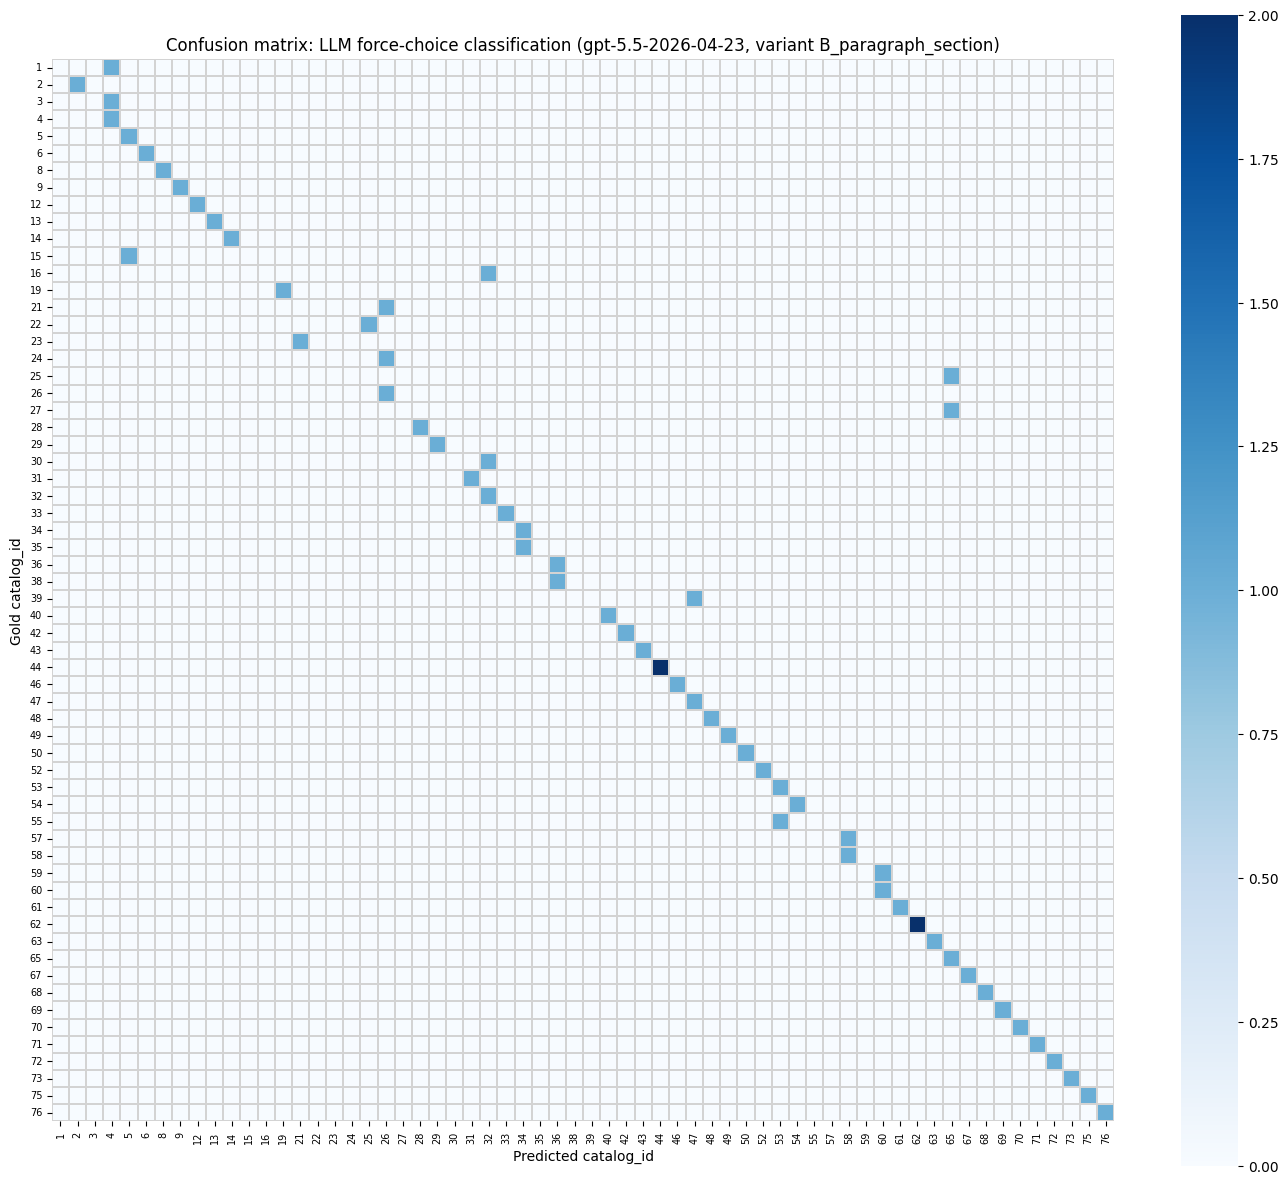

In [16]:
labels_in_use = sorted(set(y_true) | set(y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels_in_use)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True, xticklabels=labels_in_use, yticklabels=labels_in_use,
            ax=ax, square=True, linewidths=0.3, linecolor="lightgrey")
ax.set_xlabel("Predicted catalog_id")
ax.set_ylabel("Gold catalog_id")
ax.set_title(f"Confusion matrix: LLM force-choice classification ({LLM_MODEL}, variant {SELECTED_VARIANT})")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=labels_in_use, zero_division=0)

per_class_df = pd.DataFrame({
    "catalog_id": labels_in_use,
    "support": support,
    "precision": precision,
    "recall": recall,
    "f1": f1,
})
per_class_df = per_class_df.merge(catalogue[["catalog_id", "section_topic"]], on="catalog_id", how="left")
per_class_df = per_class_df[["catalog_id", "section_topic", "support", "precision", "recall", "f1"]]
per_class_df.sort_values("f1", ascending=False).head(20)

,catalog_id,section_topic,support,precision,recall,f1
61,76,"Gibt es eine Regelung, was gilt bei höherer Ge...",1,1.0,1.0,1.0
21,28,Wird eine Mindestverfügbarkeit des SaaS-Dienst...,1,1.0,1.0,1.0
24,31,"Gibt es Vereinbarungen für den Fall, dass der ...",1,1.0,1.0,1.0
26,33,Werden Datensicherungs- und Disaster-Recovery-...,1,1.0,1.0,1.0
50,62,Sind bestimmte Schäden von der Haftung ausgesc...,2,1.0,1.0,1.0
49,61,Ist die Haftung der Höhe nach begrenzt (z.B. a...,1,1.0,1.0,1.0
1,2,Ist das Vergütungsmodell eindeutig festgelegt ...,1,1.0,1.0,1.0
32,40,Ist der Einsatz von Unterauftragsverarbeitern ...,1,1.0,1.0,1.0
33,42,Sind die Mitwirkungspflichten des Kunden klar ...,1,1.0,1.0,1.0
34,43,Sind die Pflichten des Anbieters und der Leist...,1,1.0,1.0,1.0


## Step 11: Save outputs

In [18]:
predictions_df.to_csv(RESULTS_DIR / "predictions.csv", index=False)

all_runs_df = pd.DataFrame({
    "contract": sections["contract"].values,
    "paragraph": sections["paragraph"].values,
    "section": sections["section"].values,
    "gold_catalog_id": sections["catalog_id"].values,
    **{f"run_{i+1}_prediction": preds for i, preds in enumerate(all_predictions_per_run)},
})
all_runs_df.to_csv(RESULTS_DIR / "all_runs_predictions.csv", index=False)

metrics_output = {
    "model": LLM_MODEL,
    "selected_variant": SELECTED_VARIANT,
    "seed": SEED,
    "n_sections": int(len(sections)),
    "n_catalogue_entries": int(len(catalogue)),
    "n_unique_gold_classes": int(sections["catalog_id"].nunique()),
    "point_metrics": point_metrics,
    "bootstrap_ci": ci_results,
    "n_bootstrap_resamples": N_BOOTSTRAP_RESAMPLES,
    "stability_score": float(stability),
    "n_stability_runs": N_STABILITY_RUNS,
    "n_unstable_sections": int((~is_stable).sum()),
    "total_cost_usd": float(total_stability_cost),
    "delay_between_calls_seconds": DELAY_BETWEEN_CALLS,
}
with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics_output, f, indent=2)

per_class_df.to_csv(RESULTS_DIR / "per_class_breakdown.csv", index=False)
run_summary.to_csv(RESULTS_DIR / "stability_runs.csv")
if len(instability_df) > 0:
    instability_df.to_csv(RESULTS_DIR / "instability_map.csv", index=False)

print("Saved to results/llm/:")
for f in sorted(RESULTS_DIR.iterdir()):
    if f.name != ".gitkeep":
        print(f"  {f.name}")

Saved to results/llm/:
  all_runs_predictions.csv
  confusion_matrix.png
  instability_map.csv
  metrics.json
  per_class_breakdown.csv
  predictions.csv
  stability_runs.csv


## Summary

| Artefact | File |
|---|---|
| Predictions with reasoning per section (primary run) | `results/llm/predictions.csv` |
| All five runs side by side | `results/llm/all_runs_predictions.csv` |
| Aggregated metrics with bootstrap CIs | `results/llm/metrics.json` |
| Per-class precision, recall, F1 | `results/llm/per_class_breakdown.csv` |
| Metric variability across N=5 runs | `results/llm/stability_runs.csv` |
| Sections with prediction variability | `results/llm/instability_map.csv` |
| Confusion matrix plot | `results/llm/confusion_matrix.png` |

